For an arbitrary real field $\xi$, define the Stress field $S(t,\omega)$ in the time and frequency domain via the Wigner Transform:

$$  S(t,\omega) =  \frac{1}{\pi a} \int \mathrm{d}t^{\prime}  \xi(t+t^{\prime}) \xi(t-t^{\prime}) e^{2i\omega t^{\prime}\frac{1}{a}},$$

with some constant $a$ (In QM: $a=\hbar$). To fix the constant, consider the expected stress of a Gaussian standard variable $\xi\hookleftarrow \mathcal{G}(0,\mathbf{1})$:

$$ \langle S(t,\omega)\rangle =  \frac{1}{\pi a} \int \mathrm{d}t^{\prime} \bigg\langle \xi(t+t^{\prime}) \xi(t-t^{\prime})\bigg\rangle_{(\xi)} e^{2i\omega t^{\prime}\frac{1}{a}}=\frac{1}{\pi a} \int \mathrm{d}t^{\prime} \delta(t^{\prime}) e^{2i\omega t^{\prime}\frac{1}{a}}=\frac{1}{\pi a},$$

so let $a\equiv \frac{1}{\pi}$, such that

$$S(t,\omega) =   \int \mathrm{d}t^{\prime}  \xi(t+t^{\prime}) \xi(t-t^{\prime}) e^{2\pi i\omega t^{\prime}}$$

gives an overall expected stress of $1$ for a Gaussian standard variable. The discretization of this is

$$S(t_i,\omega_j \mid \xi)\approx \Delta t^{\prime} \sum_{l=0}^{\mathrm{min}\{N-1-i, i\}} \big( \xi^{i+l} \big) \big( \xi^{i-l}\big)  e^{2\pi i\omega_j t^{\prime}_l}.$$

This has to be evaluated for all $(t_i, \omega_j)$ combinations. $t_i$ goes from $t_0, ..., t_{N-1}$ and the wave numbers go in steps of $2\pi/L\cdot n$ where $n\in \mathbb{Z}$, max wave number is the Nyquist frequency $\pi/\Delta x$.

In [138]:
import nifty8 as ift
import numpy as np
import matplotlib.pyplot as plt

In [126]:
n_pix = 20
length = 2
t_space = ift.RGSpace(shape=(n_pix,), distances=length/n_pix)
time = np.linspace(0, length, n_pix)

random_xi = np.random.randn(n_pix)

In [129]:
def S(xi, t, real_rg_space: ift.RGSpace):
    N = real_rg_space.shape[0]
    L = real_rg_space.distances[0] * N

    h_space = real_rg_space.get_default_codomain()
    unique_omegas_cycles = h_space.get_unique_k_lengths()  # so here, the max value is 1/(2Δx) in units of length^-1 called "cycles per unit length". To get ordinary nyquist frequency in radians/length (angular wavenumber), multiply with 2pi.

    unique_angular_omegas = 2*np.pi*unique_omegas_cycles

    S_matrix = np.zeros((N,len(unique_angular_omegas)), dtype=complex)
    dt = L/N

    for i in range(N):
        for j in range(len(unique_angular_omegas)):
            omega_j = unique_angular_omegas[j]

            to_sum = []
            for l in range(min(N-i, i)):
                val = xi[i+l] * xi[i-l] * np.exp(1j * omega_j * t[l])  # note that I am not adding the 2pi factor here because omega_j is already in rad/time!
                to_sum.append(val)
            res = dt * np.sum(to_sum)
            S_matrix[i,j] = res

    return S_matrix


def S_vectorized(xi, t, real_rg_space):
    """
    Using advanced indexing - potentially faster for large arrays.
    Courtesy of Claude. I unit-tested that this is the same to approximately machine precision (~ e-300) as the original tri-nested loop form above.
    To unit-test:

        n_pix = 20
        length = 2
        t_space = ift.RGSpace(shape=(n_pix,), distances=length/n_pix)
        time = np.linspace(0, length, n_pix)

        random_xi = np.random.randn(n_pix)

    """
    N = real_rg_space.shape[0]
    L = real_rg_space.distances[0] * N
    dt = L / N

    h_space = real_rg_space.get_default_codomain()
    unique_omegas_cycles = h_space.get_unique_k_lengths()
    unique_angular_omegas = 2 * np.pi * unique_omegas_cycles
    n_omegas = len(unique_angular_omegas)

    # Pre-allocate result matrix
    S_matrix = np.zeros((N, n_omegas), dtype=complex)

    # For each i, we need to compute sums over valid l values
    for i in range(N):
        max_l_for_i = min(N - i, i)
        if max_l_for_i == 0:
            continue

        # Get valid l indices
        l_vals = np.arange(max_l_for_i)

        # Compute xi products for this i
        xi_prod = xi[i + l_vals] * xi[i - l_vals]  # Shape: (max_l_for_i,)

        # Compute exponential terms for all omegas
        # Broadcasting: t[l_vals] shape (max_l_for_i,), omegas shape (n_omegas,)
        exp_matrix = np.exp(1j * unique_angular_omegas[None, :] * t[l_vals][:, None])
        # exp_matrix shape: (max_l_for_i, n_omegas)

        # Compute products and sum over l
        products = xi_prod[:, None] * exp_matrix  # Shape: (max_l_for_i, n_omegas)
        S_matrix[i, :] = dt * np.sum(products, axis=0)

    return S_matrix


In [130]:
stress_field = S(random_xi, time, t_space)
stress_field_2 = S_vectorized(random_xi, time, t_space)

In [131]:
are_close = np.allclose(stress_field, stress_field_2, atol=1e-300)
print("Are the two stress fields close?", are_close)

Are the two stress fields close? True


In [132]:
n_pix = 20
length = 2
t_space = ift.RGSpace(shape=(n_pix,), distances=length/n_pix)
time = np.linspace(0, length, n_pix)

random_xi = np.random.randn(n_pix)

In [133]:
stress_field = S_vectorized(random_xi, time, t_space)

In [134]:
def imag_ratio(mat):
    # How 'imaginary' are the matrix elements? If this is close to 0, the matrix is effectively real.
    imag_norm = np.linalg.norm(mat.imag, 'fro')
    real_norm = np.linalg.norm(mat.real, 'fro')
    return imag_norm / (real_norm + 1e-15)

In [135]:
imag_ratio(stress_field)

0.685351496245906

In [136]:
# does the realness increase when I average over multiple random xi_s? (axis = 0 arithmetic mean)
collection_of_S_mats = []
for _ in range(1000):
    random_xi = np.random.randn(n_pix)
    S_mat = S_vectorized(random_xi, time, t_space)
    collection_of_S_mats.append(S_mat)

In [137]:
average_stress_field = np.mean(collection_of_S_mats, axis=0)
imag_ratio(average_stress_field)

0.04732752993199435

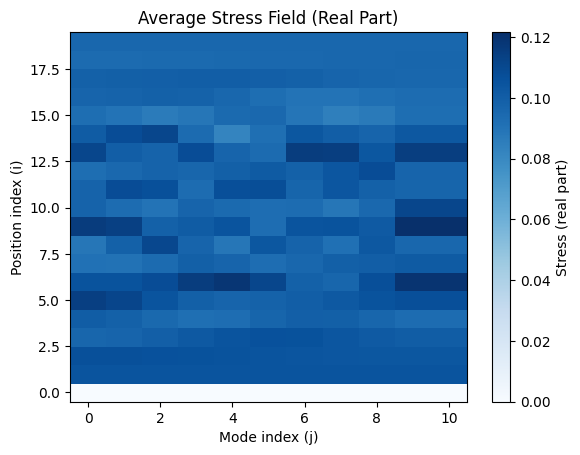

In [142]:
import matplotlib.pyplot as plt

plt.imshow(average_stress_field.real, origin='lower', aspect='auto', cmap='Blues')
plt.colorbar(label='Stress (real part)')
plt.xlabel('Mode index (j)')
plt.ylabel('Position index (i)')
plt.title('Average Stress Field (Real Part)')
plt.show()